In [9]:
from pathlib import Path

import pandas as pd
import requests
from io import StringIO

# Raw URL of the file on GitHub (replace with your own file path)
raw_url = (
    "https://raw.githubusercontent.com/"
    "Ayomide-Fagbolade/ham10000-multimodal-fusion/main/outputs"
)


# Fetch the content
train_response = requests.get(f"{raw_url}/train_split.csv")
val_response = requests.get(f"{raw_url}/val_split.csv")

train_response.raise_for_status()
val_response.raise_for_status()

# Convert the CSV text into a pandas DataFrame
train_df = pd.read_csv(StringIO(train_response.text))
val_df = pd.read_csv(StringIO(val_response.text))

train_df.shape, val_df.shape

((7966, 9), (996, 9))

In [10]:
train_df.columns

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'image_path', 'label'],
      dtype='object')

In [11]:
train_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path,label
0,HAM_0002615,ISIC_0033413,akiec,histo,70.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...,0
1,HAM_0004139,ISIC_0027496,nv,follow_up,60.0,female,lower extremity,/kaggle/input/datasets/kmader/skin-cancer-mnis...,5
2,HAM_0002704,ISIC_0031638,nv,follow_up,45.0,female,lower extremity,/kaggle/input/datasets/kmader/skin-cancer-mnis...,5
3,HAM_0001801,ISIC_0033293,nv,histo,35.0,female,abdomen,/kaggle/input/datasets/kmader/skin-cancer-mnis...,5
4,HAM_0002947,ISIC_0031589,nv,follow_up,35.0,male,trunk,/kaggle/input/datasets/kmader/skin-cancer-mnis...,5


columns of importance age, sex, localization

In [14]:
train_df.sex.value_counts()

,count
sex,
male,4339
female,3619
unknown,8


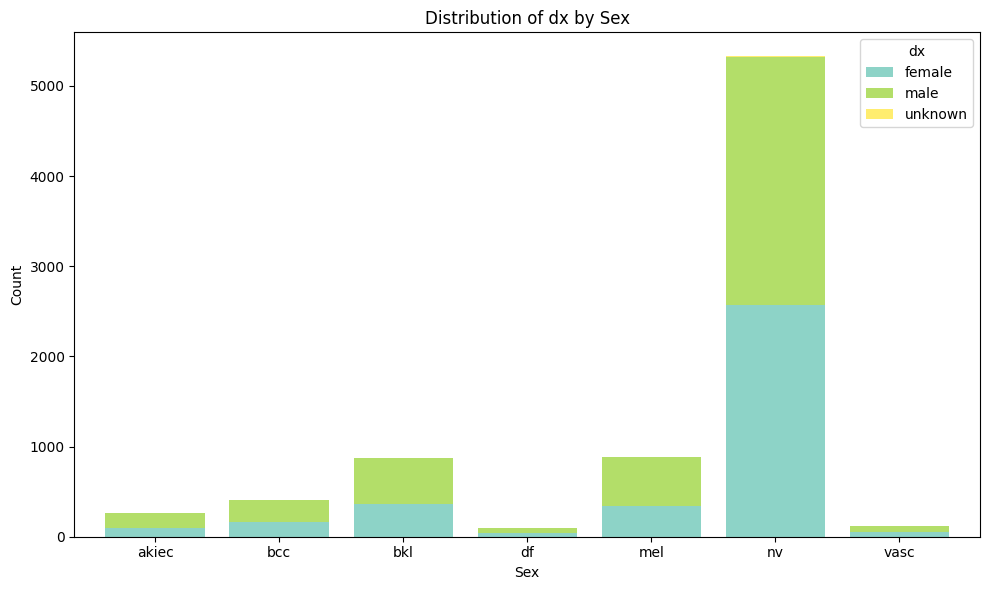

In [15]:
import matplotlib.pyplot as plt

# Count diagnoses within each sex; stacks are dx, clusters are sex
counts = train_df.groupby(["dx", "sex"]).size().unstack()

ax = counts.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    width=0.8,
    colormap="Set3",
)

ax.set_title("Distribution of dx by Sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Count")
ax.legend(title="dx")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

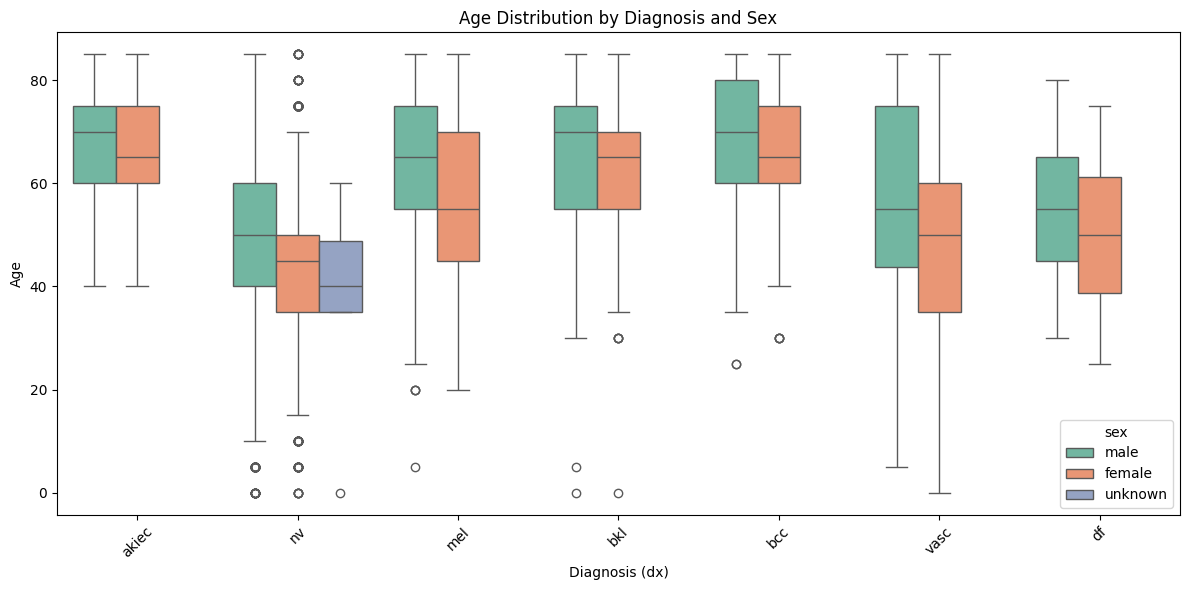

In [16]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=train_df, x="dx", y="age", hue="sex", palette="Set2")
plt.title("Age Distribution by Diagnosis and Sex")
plt.xlabel("Diagnosis (dx)")
plt.ylabel("Age")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path

fig_dir = Path("figures")
fig_dir.mkdir(parents=True, exist_ok=True)

ax.figure.tight_layout()
ax.figure.savefig(fig_dir / "distribution_dx_by_sex.png", dpi=300, bbox_inches="tight")